# Análise Geográfica do Perfil Educacional dos Eleitores de São Paulo (2022)

**Autor:** Mauro Santos

## Sumário
* [1. Introdução](#introducao)
* [2. Configuração do Ambiente](#configuracao)
* [3. Carregamento e Processamento dos Dados](#processamento)
* [4. Agregação e Transformação por Município](#agregacao)
* [5. Visualização Geográfica dos Dados](#visualizacao)
* [6. Conclusão e Próximos Passos](#conclusao)

---

## 1. Introdução <a name="introducao"></a>
Este projeto tem como objetivo realizar uma análise detalhada do perfil educacional dos eleitores do estado de São Paulo. Utilizando dados públicos do [Repositório de Dados Eleitorais do TSE](https://dados.tse.jus.br/dataset/eleitorado-por-secao-eleitoral) referentes ao ano de 2022, investigamos a distribuição geográfica dos diferentes níveis de escolaridade por todo o estado.

Um dos principais desafios técnicos deste projeto foi o manuseio de um arquivo de dados massivo (5GB), o que exigiu uma abordagem de processamento em partes (*chunks*) para garantir a eficiência computacional sem sobrecarregar a memória.

O resultado final são mapas coropléticos, estáticos e interativos, que revelam a proporção de eleitores por faixa de escolaridade em cada município, permitindo uma análise visual clara e comparativa.

**Ferramentas utilizadas:** Python, Pandas, GeoPandas e Matplotlib.

## 2. Configuração do Ambiente <a name="configuracao"></a>
Nesta seção, realizamos a configuração inicial do nosso ambiente de trabalho. Isso inclui:
* Montagem do Google Drive para acessar nossos arquivos de dados (CSV e Shapefile).
* Instalação das bibliotecas geoespaciais necessárias, como o `geopandas`.
* Importação de todas as bibliotecas que serão utilizadas ao longo do projeto.

In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
caminho_csv = '/data/perfil_eleitor_secao_2022_SP.csv'
caminho_shapefile = '/data/SP_Municipios_2024.shp'

## 3. Carregamento e Processamento dos Dados <a name="processamento"></a>
O arquivo de dados original do TSE possui 5GB, um tamanho que pode exceder a memória RAM disponível em ambientes como o Google Colab. Para contornar essa limitação, lemos o arquivo CSV em "pedaços" (*chunks*).

Para cada pedaço, filtramos imediatamente apenas os registros pertencentes ao estado de São Paulo (`SG_UF == 'SP'`) e selecionamos somente as colunas relevantes para a análise. Essa abordagem otimizada nos permite processar a totalidade do arquivo de forma eficiente.

In [28]:
tamanho_chunk = 500000
lista_chunks_sp = []

leitor_csv = pd.read_csv(
    caminho_csv,
    encoding='latin-1',
    sep=';',
    chunksize=tamanho_chunk,
    usecols=['SG_UF', 'NM_MUNICIPIO', 'DS_GRAU_ESCOLARIDADE', 'QT_ELEITORES_PERFIL'] # Seleciona apenas colunas úteis
)

print("Iniciando a leitura e filtragem do arquivo CSV...")

for chunk in leitor_csv:
    # chunk_sp = chunk[chunk['SG_UF'] == 'SP']
    lista_chunks_sp.append(chunk)

df_sp = pd.concat(lista_chunks_sp)

print(f"Processamento concluído! Total de {len(df_sp)} registros encontrados para SP.")
df_sp.head()

Iniciando a leitura e filtragem do arquivo CSV...
Processamento concluído! Total de 16507806 registros encontrados para SP.


,SG_UF,NM_MUNICIPIO,DS_GRAU_ESCOLARIDADE,QT_ELEITORES_PERFIL
0,SP,ARAÇATUBA,LÊ E ESCREVE,2
1,SP,ARAÇATUBA,ENSINO FUNDAMENTAL INCOMPLETO,1
2,SP,ARAÇATUBA,ANALFABETO,1
3,SP,ARAÇATUBA,ENSINO FUNDAMENTAL INCOMPLETO,1
4,SP,ARAÇATUBA,ENSINO FUNDAMENTAL INCOMPLETO,1


## 4. Agregação e Transformação por Município <a name="agregacao"></a>
Com os dados de São Paulo carregados, o próximo passo é transformá-los para a análise. Agrupamos os dados por município e grau de escolaridade para obter o total de eleitores em cada categoria.

O passo mais importante aqui é o cálculo da **proporção percentual**. Em vez de usar números absolutos, calculamos o percentual que cada nível de escolaridade representa dentro do total de eleitores de seu próprio município. Isso nos permite criar mapas mais justos e comparáveis, evitando que cidades com mais eleitores, como a capital, mascarem os padrões de distribuição das demais.

In [29]:
print("Agregando dados por município e grau de escolaridade...")
df_agregado = df_sp.groupby(['NM_MUNICIPIO', 'DS_GRAU_ESCOLARIDADE'])['QT_ELEITORES_PERFIL'].sum().reset_index()

df_pivot = df_agregado.pivot(
    index='NM_MUNICIPIO',
    columns='DS_GRAU_ESCOLARIDADE',
    values='QT_ELEITORES_PERFIL'
).reset_index()

df_pivot = df_pivot.fillna(0)
colunas_escolaridade = df_pivot.columns.drop('NM_MUNICIPIO')
df_pivot['TOTAL_ELEITORES'] = df_pivot[colunas_escolaridade].sum(axis=1)

for coluna in colunas_escolaridade:
    df_pivot[f'{coluna}_PERC'] = (df_pivot[coluna] / df_pivot['TOTAL_ELEITORES']) * 100

print("Dados agregados e proporções calculadas com sucesso!")
df_pivot.head()

Agregando dados por município e grau de escolaridade...
Dados agregados e proporções calculadas com sucesso!


DS_GRAU_ESCOLARIDADE,NM_MUNICIPIO,ANALFABETO,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,NÃO INFORMADO,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO,TOTAL_ELEITORES,ANALFABETO_PERC,ENSINO FUNDAMENTAL COMPLETO_PERC,ENSINO FUNDAMENTAL INCOMPLETO_PERC,ENSINO MÉDIO COMPLETO_PERC,ENSINO MÉDIO INCOMPLETO_PERC,LÊ E ESCREVE_PERC,NÃO INFORMADO_PERC,SUPERIOR COMPLETO_PERC,SUPERIOR INCOMPLETO_PERC
0,ADAMANTINA,879.0,1857.0,6272.0,8235.0,2706.0,589.0,0.0,5567.0,1622.0,27727.0,3.170195,6.697443,22.620550,29.700292,9.759440,2.124283,0.0,20.077902,5.849894
1,ADOLFO,214.0,352.0,1287.0,1145.0,536.0,174.0,0.0,435.0,167.0,4310.0,4.965197,8.167053,29.860789,26.566125,12.436195,4.037123,0.0,10.092807,3.874710
2,AGUAÍ,947.0,1947.0,7328.0,6285.0,3412.0,705.0,0.0,2531.0,954.0,24109.0,3.927994,8.075822,30.395288,26.069103,14.152391,2.924219,0.0,10.498154,3.957028
3,AGUDOS,1224.0,2062.0,6333.0,10507.0,3749.0,1151.0,0.0,3809.0,1697.0,30532.0,4.008909,6.753570,20.742172,34.413075,12.278920,3.769815,0.0,12.475436,5.558103
4,ALAMBARI,136.0,371.0,1429.0,1604.0,662.0,202.0,0.0,376.0,153.0,4933.0,2.756943,7.520778,28.968174,32.515711,13.419826,4.094871,0.0,7.622137,3.101561


In [30]:
print("Carregando o arquivo shapefile...")

gdf_sp_mapa = gpd.read_file(caminho_shapefile)
coluna_nome_municipio_shp = 'NM_MUN'
df_pivot['chave_juncao'] = df_pivot['NM_MUNICIPIO'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()
gdf_sp_mapa['chave_juncao'] = gdf_sp_mapa[coluna_nome_municipio_shp].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()

mapa_final = gdf_sp_mapa.merge(
    df_pivot,
    on='chave_juncao',
    how='left'
)

print("Shapefile carregado e unido aos dados de eleitores.")
mapa_final.head()

Carregando o arquivo shapefile...
Shapefile carregado e unido aos dados de eleitores.


,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,...,TOTAL_ELEITORES,ANALFABETO_PERC,ENSINO FUNDAMENTAL COMPLETO_PERC,ENSINO FUNDAMENTAL INCOMPLETO_PERC,ENSINO MÉDIO COMPLETO_PERC,ENSINO MÉDIO INCOMPLETO_PERC,LÊ E ESCREVE_PERC,NÃO INFORMADO_PERC,SUPERIOR COMPLETO_PERC,SUPERIOR INCOMPLETO_PERC
0,3513009,Cotia,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,...,185031.0,1.700796,6.829666,21.042420,31.159103,19.596716,3.047597,0.0,11.490507,5.133194
1,3532827,Nova Campina,350004,Itapeva,3502,Sorocaba,35,São Paulo,SP,3,...,7126.0,7.072692,6.132473,19.730564,29.609879,15.534662,15.801291,0.0,4.209935,1.908504
2,3502507,Aparecida,350052,Guaratinguetá,3511,São José dos Campos,35,São Paulo,SP,3,...,28587.0,1.231329,9.255956,20.177004,34.820023,12.544163,2.102354,0.0,14.688495,5.180677
3,3543303,Ribeirão Pires,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,...,90990.0,1.697989,6.428179,17.761292,37.546983,12.480492,2.451918,0.0,15.727003,5.906144
4,3542008,Quintana,350013,Marília,3504,Marília,35,São Paulo,SP,3,...,5475.0,2.721461,7.068493,30.958904,29.278539,16.694064,3.196347,0.0,7.671233,2.410959


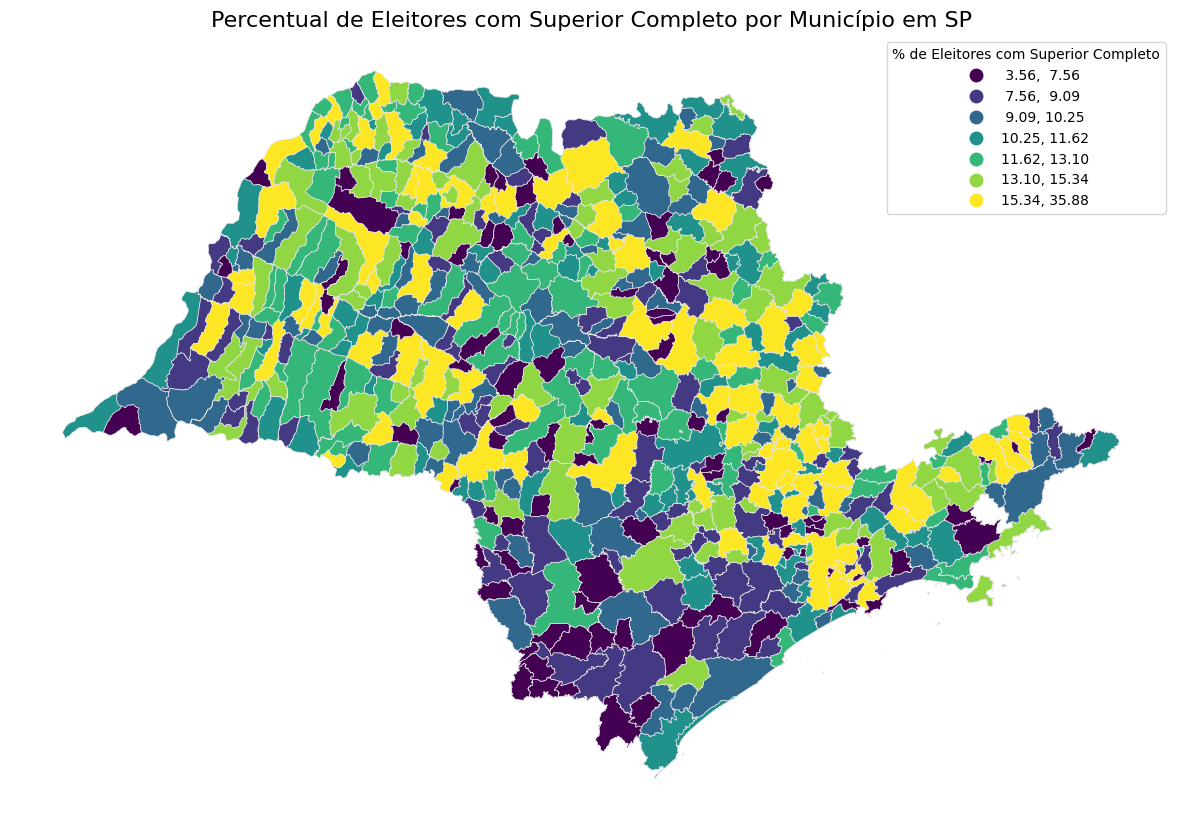

In [33]:
coluna_para_plotar = 'SUPERIOR COMPLETO_PERC'

if coluna_para_plotar not in mapa_final.columns:
    print(f"Erro: A coluna '{coluna_para_plotar}' não foi encontrada.")
    print("Verifique se o Bloco 4 ajustado foi executado corretamente.")
else:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    mapa_final.plot(
        column=coluna_para_plotar,
        cmap='viridis',
        linewidth=0.5,
        ax=ax,
        edgecolor='0.9',
        legend=True,
        scheme='quantiles',
        k=7,
        legend_kwds={'title': f"% de Eleitores com Superior Completo"}
    )

    ax.axis('off')
    ax.set_title(f'Percentual de Eleitores com Superior Completo por Município em SP', fontdict={'fontsize': '16', 'fontweight': '3'})
    plt.show()

## 5. Visualização Geográfica dos Dados <a name="visualizacao"></a>
Esta é a etapa central da nossa análise. Unimos nossos dados agregados ao arquivo Shapefile dos municípios de São Paulo para gerar as visualizações geográficas.

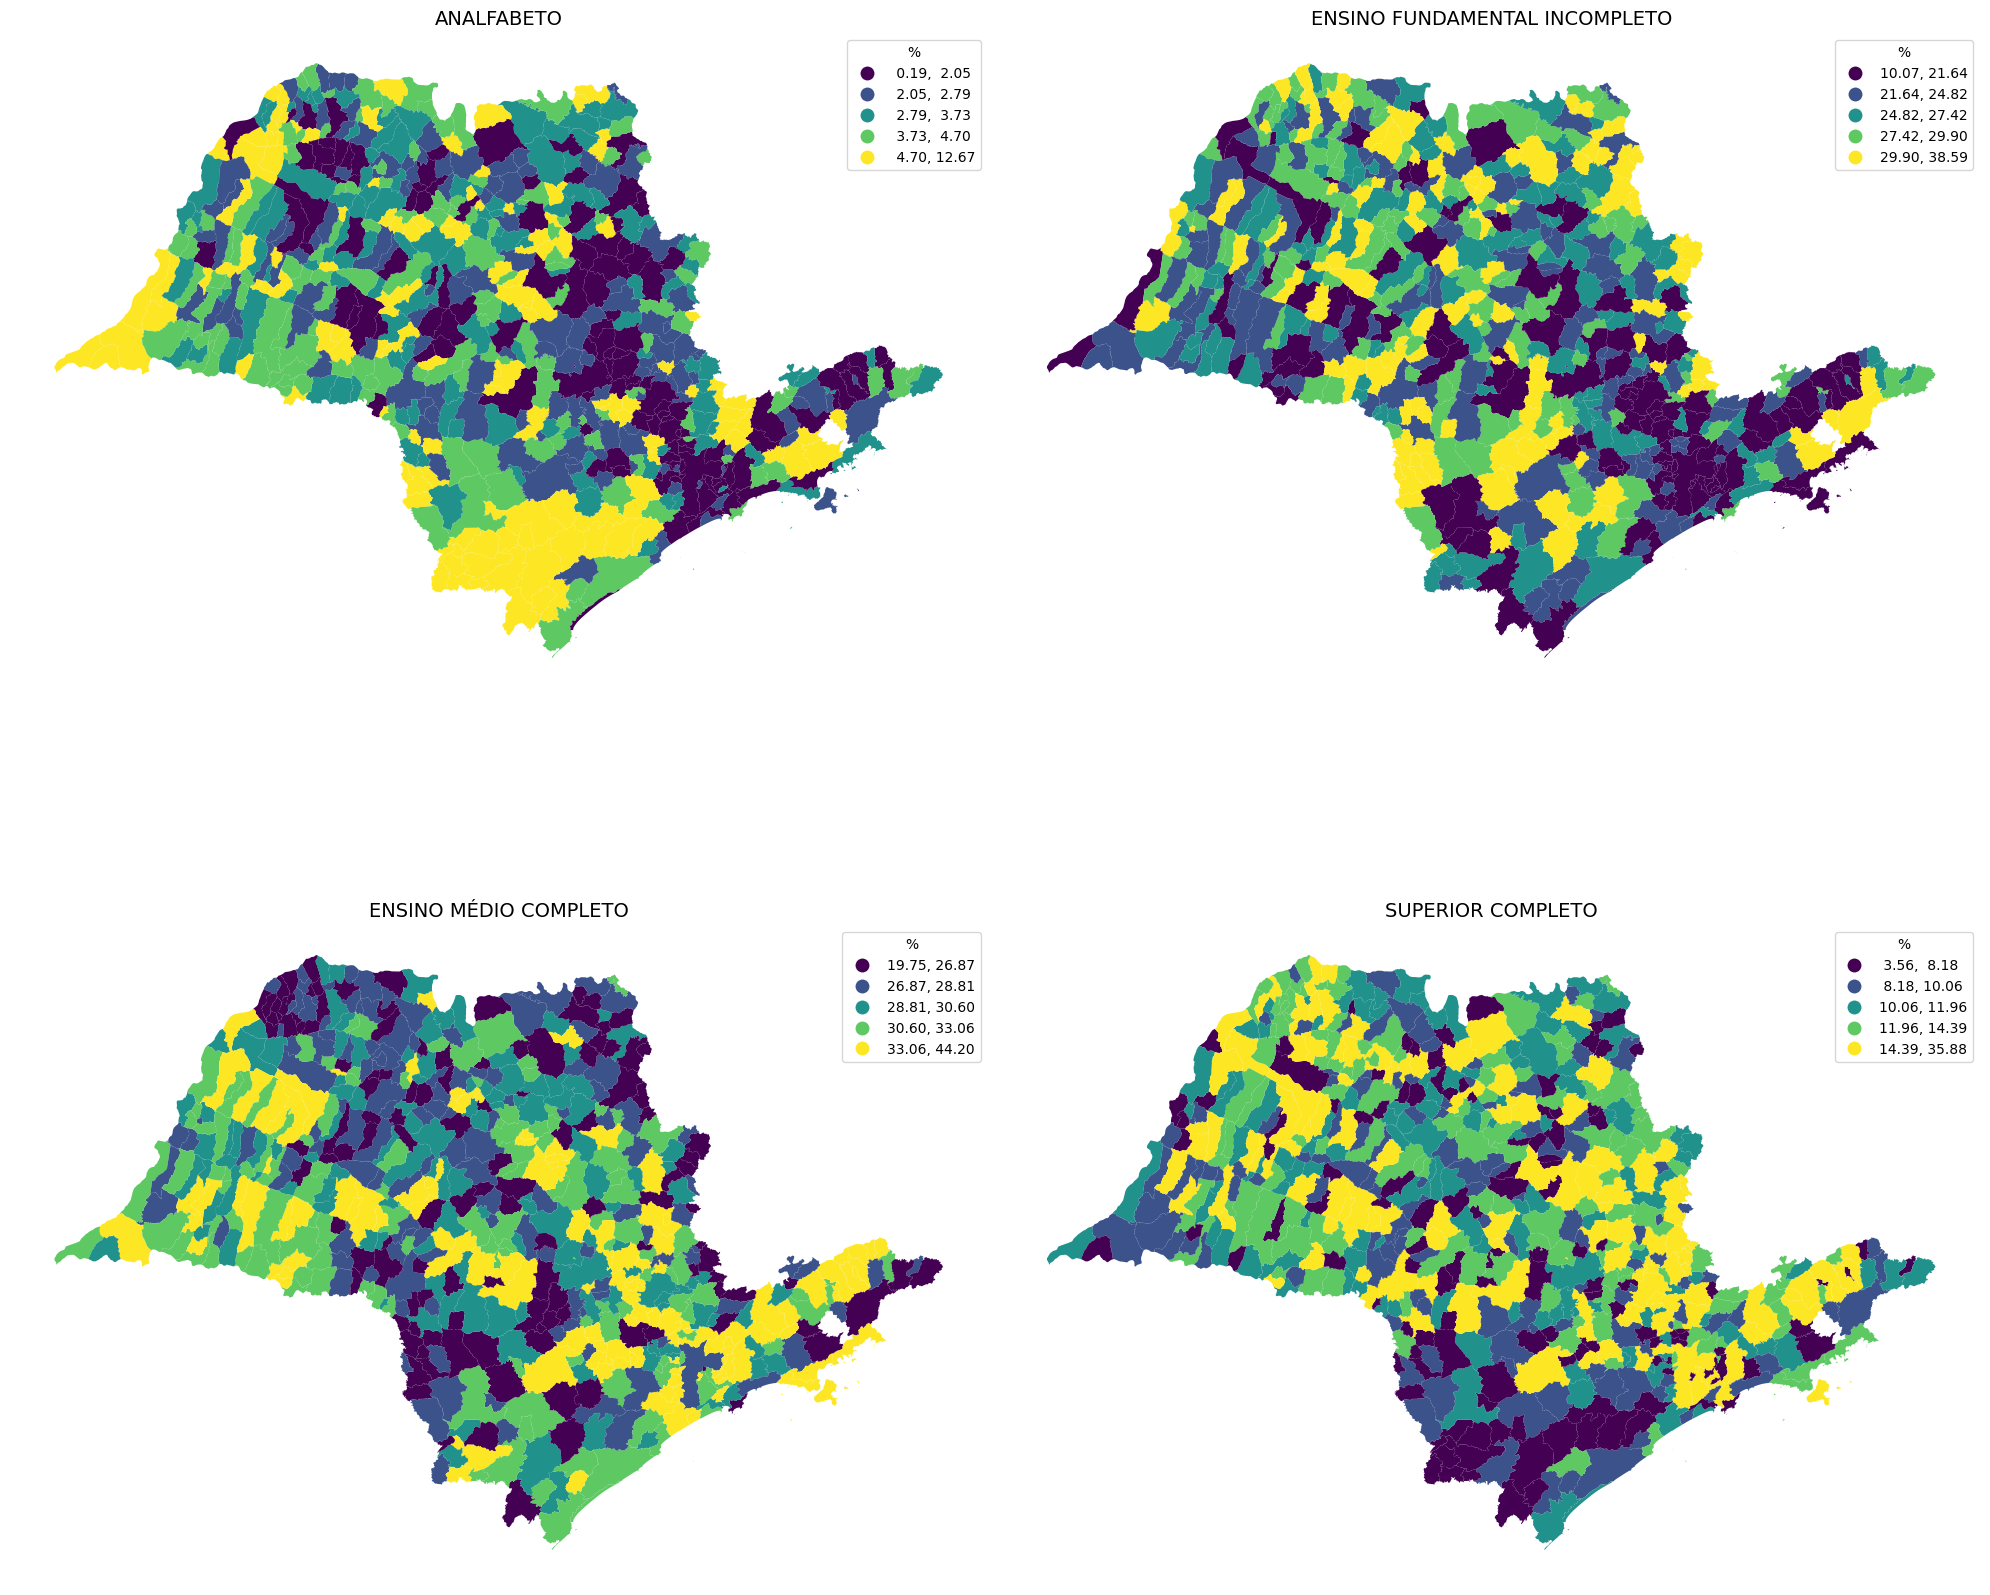

In [34]:
colunas_para_plotar = [
    'ANALFABETO_PERC',
    'ENSINO FUNDAMENTAL INCOMPLETO_PERC',
    'ENSINO MÉDIO COMPLETO_PERC',
    'SUPERIOR COMPLETO_PERC'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, coluna in enumerate(colunas_para_plotar):
    ax = axes[i]
    mapa_final.plot(
        column=coluna,
        ax=ax,
        legend=True,
        cmap='viridis',
        scheme='quantiles',
        k=5,
        legend_kwds={'title': '%'}
    )
    ax.set_title(coluna.replace('_PERC', ''), fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Conclusão <a name="conclusao"></a>

Nesta análise, foi possível observar que a Zona sul do estado tem alta concentração de municípios com eleitores analfabetos e que, em contraste, não há muitos eleitores com ensino superior completo, nota-se também que eleitores de municípios próximos à região metropolitana de São Paulo tendem a serem melhores instruídos, principalmente na região do Vale do Paraíba e centro-oeste do estado.